In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [13]:
scaler = StandardScaler()

# Scale training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Autoencoder only on normal data
X_normal = X_train_scaled[y_train == 0]
X_tr, X_val = train_test_split(X_normal, test_size=0.1, random_state=42)

print(f"Normal training samples: {len(X_tr)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test_scaled)}")
print(f"Test threats: {sum(y_test==1)}, Test normal: {sum(y_test==0)}")

Normal training samples: 236805
Validation samples: 26312
Test samples: 66054
Test threats: 265, Test normal: 65789


In [14]:
import pandas as pd

X_train = pd.read_csv('../../data/processed/X_train.csv').values
X_test = pd.read_csv('../../data/processed/X_test.csv').values
y_train = pd.read_csv('../../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../../data/processed/y_test.csv').values.ravel()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Train threats: {sum(y_train==1)}, Train normal: {sum(y_train==0)}")
print(f"Test threats:  {sum(y_test==1)}, Test normal:  {sum(y_test==0)}")

X_train shape: (526234, 6)
X_test shape:  (66054, 6)
Train threats: 263117, Train normal: 263117
Test threats:  265, Test normal:  65789


In [15]:
input_dim = X_tr.shape[1]  # 6 features

inputs = Input(shape=(input_dim,))

# Encoder — compresses the data
encoded = Dense(64, activation='relu')(inputs)
encoded = Dense(32, activation='relu')(encoded)
bottleneck = Dense(16, activation='relu')(encoded)

# Decoder — reconstructs the data
decoded = Dense(32, activation='relu')(bottleneck)
decoded = Dense(64, activation='relu')(decoded)
outputs = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,102 (23.84 KB)

 Trainable params: 6,102 (23.84 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, X_val),
    shuffle=True,
    verbose=1
)

Epoch 1/50
16445/16445 ━━━━━━━━━━━━━━━━━━━━ 8s 421us/step - loss: 66.1745 - val_loss: 1.4921
Epoch 2/50
16445/16445 ━━━━━━━━━━━━━━━━━━━━ 7s 412us/step - loss: 0.1929 - val_loss: 1.5447
Epoch 3/50
16445/16445 ━━━━━━━━━━━━━━━━━━━━ 7s 404us/step - loss: 0.1588 - val_loss: 1.9307
Epoch 4/50
16445/16445 ━━━━━━━━━━━━━━━━━━━━ 7s 406us/step - loss: 0.1296 - val_loss: 3.0235
Epoch 5/50
16445/16445 ━━━━━━━━━━━━━━━━━━━━ 7s 421us/step - loss: 0.1199 - val_loss: 3.1318
Epoch 6/50
16445/16445 ━━━━━━━━━━━━━━━━━━━━ 7s 426us/step - loss: 0.0987 - val_loss: 3.0554
Epoch 7/50
16445/16445 ━━━━━━━━━━━━━━━━━━━━ 7s 403us/step - loss: 0.0910 - val_loss: 3.3661
Epoch 8/50
16445/16445 ━━━━━━━━━━━━━━━━━━━━ 7s 410us/step - loss: 0.0867 - val_loss: 3.8875
Epoch 9/50
16445/16445 ━━━━━━━━━━━━━━━━━━━━ 7s 446us/step - loss: 0.0807 - val_loss: 4.1590
Epoch 10/50
16445/16445 ━━━━━━━━━━━━━━━━━━━━ 7s 448us/step - loss: 0.0748 - val_loss: 5.4565
Epoch 11/50
16445/16445 ━━━━━━━━━━━━━━━━━━━━ 7s 447us/step - loss: 0.0690 - va

In [17]:
import pandas as pd

X_train = pd.read_csv('../../data/processed/X_train.csv').values
X_test = pd.read_csv('../../data/processed/X_test.csv').values
y_train = pd.read_csv('../../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../../data/processed/y_test.csv').values.ravel()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Train threats: {sum(y_train==1)}, Train normal: {sum(y_train==0)}")
print(f"Test threats:  {sum(y_test==1)}, Test normal:  {sum(y_test==0)}")

X_train shape: (526234, 6)
X_test shape:  (66054, 6)
Train threats: 263117, Train normal: 263117
Test threats:  265, Test normal:  65789


In [18]:
X_pred = autoencoder.predict(X_test)
reconstruction_error = np.mean(np.power(X_test - X_pred, 2), axis=1)

print(f"Max reconstruction error: {reconstruction_error.max():.4f}")
print(f"Min reconstruction error: {reconstruction_error.min():.4f}")
print(f"Mean reconstruction error: {reconstruction_error.mean():.4f}")

2065/2065 ━━━━━━━━━━━━━━━━━━━━ 0s 220us/step
Max reconstruction error: 83.0558
Min reconstruction error: 0.0001
Mean reconstruction error: 0.0041


In [19]:
# Threshold = 95th percentile of training reconstruction error
train_pred = autoencoder.predict(X_train)
train_error = np.mean(np.power(X_train - train_pred, 2), axis=1)
threshold = np.percentile(train_error, 95)

print(f"Anomaly threshold: {threshold:.4f}")

y_pred = (reconstruction_error > threshold).astype(int)
print(f"Predicted threats: {sum(y_pred)}")
print(f"Actual threats: {sum(y_test)}")

16445/16445 ━━━━━━━━━━━━━━━━━━━━ 4s 222us/step
Anomaly threshold: 0.0052
Predicted threats: 3230
Actual threats: 265


In [20]:
print(classification_report(y_test, y_pred, target_names=['Normal', 'Threat']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, reconstruction_error):.4f}")

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     65789
      Threat       0.01      0.16      0.02       265

    accuracy                           0.95     66054
   macro avg       0.50      0.56      0.50     66054
weighted avg       0.99      0.95      0.97     66054

Confusion Matrix:
[[62602  3187]
 [  222    43]]
AUC-ROC: 0.7563


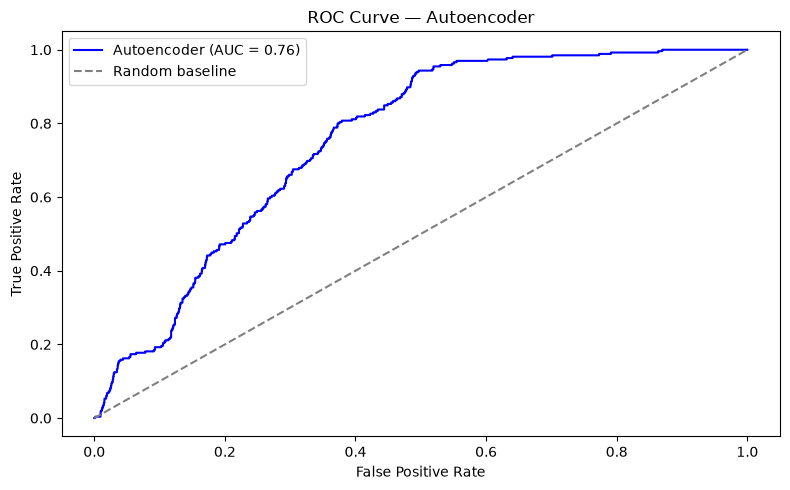

In [21]:
import os
os.makedirs('../../reports', exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, reconstruction_error)
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f'Autoencoder (AUC = {roc_auc_score(y_test, reconstruction_error):.2f})', color='blue')
plt.plot([0,1],[0,1],'--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Autoencoder')
plt.legend()
plt.tight_layout()
plt.savefig('../../reports/roc_autoencoder.png')
plt.show()